In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load the data
prices = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\vietnam_stock_price_full.csv', index_col=0, parse_dates=True)
volumes = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\vietnam_stock_volume_full.csv', index_col=0, parse_dates=True)
FU = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\FU_VN30_full_fixed.csv', index_col=0, parse_dates=True)

In [3]:
START_DATE = '2018-01-02'
END_DATE   = '2025-12-31'

In [19]:
by_exchange = pd.read_csv(r'C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\by_exchange.csv')

In [11]:
prices.head(5)

,YEG,YBM,X20,WSS,WCS,VVS,VTZ,VTV,VTP,VTO,...,ACG,ACC,ACB,ABT,ABS,ABR,AAV,AAT,AAM,AAA
2014-07-09,NaN,NaN,NaN,5.1,33.04,NaN,NaN,3.35,NaN,2.92,...,NaN,5.32,2.37,21.56,NaN,NaN,NaN,NaN,7.13,6.08
2014-07-10,NaN,NaN,NaN,5.0,33.04,NaN,NaN,3.43,NaN,2.84,...,NaN,5.07,2.35,20.25,NaN,NaN,NaN,NaN,7.08,5.90
2014-07-11,NaN,NaN,NaN,4.9,29.78,NaN,NaN,3.41,NaN,2.84,...,NaN,5.26,2.35,20.64,NaN,NaN,NaN,NaN,7.38,5.81
2014-07-14,NaN,NaN,NaN,4.9,32.64,NaN,NaN,3.56,NaN,2.84,...,NaN,5.45,2.35,20.90,NaN,NaN,NaN,NaN,7.38,5.87
2014-07-15,NaN,NaN,NaN,5.0,32.64,NaN,NaN,3.48,NaN,2.88,...,NaN,5.26,2.37,21.08,NaN,NaN,NaN,NaN,7.38,5.90


In [12]:
volumes.head(5)

,YEG,YBM,X20,WSS,WCS,VVS,VTZ,VTV,VTP,VTO,...,ACG,ACC,ACB,ABT,ABS,ABR,AAV,AAT,AAM,AAA
2014-07-09,NaN,NaN,NaN,481500.0,0.0,NaN,NaN,14200,NaN,540110,...,NaN,3500.0,62959.0,0.0,NaN,NaN,NaN,NaN,2910.0,273100.0
2014-07-10,NaN,NaN,NaN,290000.0,300.0,NaN,NaN,46100,NaN,479590,...,NaN,920.0,99422.0,7430.0,NaN,NaN,NaN,NaN,8770.0,487100.0
2014-07-11,NaN,NaN,NaN,220100.0,500.0,NaN,NaN,11300,NaN,447670,...,NaN,50.0,69344.0,5790.0,NaN,NaN,NaN,NaN,10560.0,393800.0
2014-07-14,NaN,NaN,NaN,160000.0,300.0,NaN,NaN,4200,NaN,304680,...,NaN,100.0,153409.0,1500.0,NaN,NaN,NaN,NaN,7010.0,119600.0
2014-07-15,NaN,NaN,NaN,93400.0,300.0,NaN,NaN,11800,NaN,197610,...,NaN,4930.0,70911.0,2410.0,NaN,NaN,NaN,NaN,0.0,251800.0


In [13]:
FU.head(5)

,open,high,low,close,Volume
time,,,,,
2017-08-10,0.7579,0.7579,0.7455,0.7459,367
2017-08-11,0.7460,0.7464,0.7434,0.7457,510
2017-08-14,0.7459,0.7489,0.7457,0.7489,707
2017-08-15,0.7503,0.7509,0.7480,0.7480,946
2017-08-16,0.7477,0.7484,0.7451,0.7481,1065


In [4]:
# =============================================================================
# FUNCTIONS
# =============================================================================


# 1. Data preparation and universe selection
# --- Function to select stocks with highest liquidity ---
def top_liquidity_stocks(price_df, volume_df, top_n=300, average_window=60):
    # Calculate liquidity metrics (average volume* price over lookback window)
    price_win = price_df.tail(average_window)
    volume_win = volume_df.tail(average_window)

    liquidity = (price_win * volume_win).mean()
    top_stocks = liquidity.nlargest(min(top_n, len(liquidity))).index

    return price_df[top_stocks], volume_df[top_stocks].astype(float)

# --- Fill missing values with average of 2 before and 2 after ---
def fill_na_with_2before_2after(df: pd.DataFrame, min_neighbors=1, require_all=False):
    s1 = df.shift(1)
    s2 = df.shift(2)
    s_1 = df.shift(-1)
    s_2 = df.shift(-2)

    neighbor_sum = s1.fillna(0) + s2.fillna(0) + s_1.fillna(0) + s_2.fillna(0)
    neighbor_count = (
        s1.notna().astype(int)
        + s2.notna().astype(int)
        + s_1.notna().astype(int)
        + s_2.notna().astype(int)
    )

    neighbor_mean = neighbor_sum / neighbor_count.where(neighbor_count > 0)

    if require_all:
        fill_values = neighbor_mean.where(neighbor_count == 4)
    else:
        fill_values = neighbor_mean.where(neighbor_count >= min_neighbors)

    return df.where(df.notna(), fill_values)

# --- Universe selection based on liquidity ---
def select_universe(prices_df: pd.DataFrame, volume_df: pd.DataFrame, date: pd.Timestamp, top_n=300, lookback_window=252):
    # filter stocks with price data on the given date
    index_date = prices_df.index.get_loc(date)
    list_stocks_notna_today = prices_df.columns[prices_df.loc[date].notna()]
    price = prices_df[list_stocks_notna_today].iloc[(index_date - lookback_window+1):(index_date + 1)]
    volume = volume_df[list_stocks_notna_today].iloc[(index_date - lookback_window+1):(index_date + 1)]

    # common columns
    common_columns = price.columns.intersection(volume.columns)
    price = price[common_columns]
    volume = volume[common_columns]

    # handle missing values by forward fill then drop na
    price = price.ffill(limit=2)
    price = price.dropna(axis=1, how='any')
    columns = price.columns
    volume = volume[columns]
    # fill volume missing values with average of previous and next valid values
    volume = fill_na_with_2before_2after(volume, min_neighbors=1, require_all=False)
    volume = volume.dropna(axis=1, how='any')
    columns = volume.columns
    price = price[columns]
    
    # return price and volume for the top N stocks by liquidity
    return top_liquidity_stocks(price, volume, top_n=top_n, average_window=lookback_window)

# --- Returns calculation ---
def compute_returns(price_df: pd.DataFrame, volume_df: pd.DataFrame=None, with_volume=False, volume_average_window=10):
    # basic returns calculation
    returns = price_df.pct_change().dropna()

    # volume adjustment
    if with_volume and volume_df is not None:
        volume_average = volume_df.shift(1).rolling(volume_average_window).mean().dropna() # volume average based on previous day
        volume_average = volume_average.reindex(returns.index) 
        delta_volume = volume_average.diff().dropna() 
        returns = returns*(volume_average/delta_volume)
    return returns.dropna()
# ----------------------------------------------------------------------------

# 2. PCA and factor modeling
# --- Standardize returns ---
def standardize_returns(returns_df: pd.DataFrame):
    mean_i = returns_df.mean(axis=0)
    std_i  = returns_df.std(axis=0, ddof=1).replace(0, np.nan)
    standardized = (returns_df - mean_i) / std_i
    return standardized.dropna(axis=1)

# --- Empirical correlation ---
def compute_empirical_correlation(standardized_returns: pd.DataFrame):
    M = standardized_returns.shape[0]
    return (standardized_returns.values.T @ standardized_returns.values) / (M - 1)

# --- Eigen decomposition sorted ---
def eigen_decomposition_sorted(corr_matrix: np.ndarray):
    eigvals, eigvecs = np.linalg.eigh(corr_matrix)
    idx = np.argsort(eigvals)[::-1]
    return eigvals[idx], eigvecs[:, idx]

# --- PCA engine ---
import numpy as np
import pandas as pd

def window_pca_engine(
    returns_df: pd.DataFrame,
    fixed_factors: bool = False,
    n_factors: int = 15,
    variance_cutoff: float = 0.55
):
    if returns_df.shape[1] < 2:
        raise ValueError("returns_df must contain at least 2 stocks")

    # độ lệch chuẩn từng cổ phiếu
    std_stocks = returns_df.std(ddof=1)

    # loại các cột có std = 0 hoặc NaN
    valid_cols = std_stocks[(std_stocks > 0) & std_stocks.notna()].index
    returns_df = returns_df[valid_cols]
    std_stocks = std_stocks[valid_cols]

    if returns_df.shape[1] < 2:
        raise ValueError("Not enough valid stocks after removing zero-variance columns")

    # PCA
    Z = standardize_returns(returns_df)
    C = compute_empirical_correlation(Z)
    eigvals, eigvecs = eigen_decomposition_sorted(C)

    # chọn số factor
    if fixed_factors:
        k = min(n_factors, returns_df.shape[1] - 1)
    else:
        cumvar = np.cumsum(eigvals) / eigvals.sum()
        k = int(np.searchsorted(cumvar, variance_cutoff)) + 1
        k = min(k, returns_df.shape[1] - 1)

    # eigenportfolios
    V = eigvecs[:, :k]
    Q = V / std_stocks.to_numpy().reshape(-1, 1)


    pca_dict = {
        "Q": Q,                           # quantity of stocks in each factor
        "V": V,                           # eigenvectors                                              
        "k": k,                           # number of factors
        "stocks": returns_df.columns,     # stock names
        "eigenvalues": eigvals[:k],       # eigenvalues of selected factors
    }

    return pca_dict
# ----------------------------------------------------------------------------

# 3. Model regression and residuals
# --- Compute PCA residuals ---
def compute_pca_residuals(returns_df: pd.DataFrame, pca_dict: dict, window=60):
    # take last 'window' returns for regression
    returns_win = returns_df.iloc[-window:]

    Q = pca_dict["Q"]
    stocks = pca_dict["stocks"]

    # check stocks match
    if list(stocks) != list(returns_df.columns):
        raise ValueError("PCA stocks do not match returns stocks")

    # matrix returns
    R = returns_win[stocks].values     # (window × N)

    # factor returns
    F = R @ Q                                    # (window × k)

    # design matrix with intercept
    X = np.column_stack([np.ones(window), F])     # (window × (k+1))

    # OLS solution
    XtX_inv = np.linalg.pinv(X.T @ X)
    B = XtX_inv @ (X.T @ R)                       # ((k+1) × N)

    # fitted returns
    fitted = X @ B                                # (window × N)

    # residuals
    residuals = R - fitted

    # convert to DataFrame
    residuals_df = pd.DataFrame(
        residuals,
        index=returns_win.index,
        columns=stocks
    )

    return residuals_df   

In [15]:
date_example = '2018-07-24'

In [16]:
ex_price, ex_volume = select_universe(prices, volumes,date = pd.to_datetime(date_example), top_n=300, lookback_window=252)
ex_return = compute_returns(ex_price, ex_volume, with_volume=False, volume_average_window=10)
pca_result = window_pca_engine(ex_return, fixed_factors=False, variance_cutoff=0.55)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [20]:
pca_result['Q'].shape

(296, 44)

In [21]:
ex_return

,STB,VJC,PVS,VNM,VIC,NVL,CTG,VCB,MSN,SBT,...,HKT,DP3,HJS,HAT,SHP,DBT,UNI,CIG,HMC,KLB
2017-07-25,0.054852,0.002388,-0.012488,0.000000,-0.004516,0.000000,0.026797,0.000000,0.003578,0.017603,...,-0.070681,0.018293,0.060057,0.000000,0.000000,0.005731,0.018182,0.000000,0.000000,0.011494
2017-07-26,0.024000,0.000000,0.006809,0.007913,0.014258,-0.001385,0.017794,0.002592,-0.001188,0.029812,...,0.000000,-0.004990,-0.020683,0.056911,0.003810,0.000000,0.017857,-0.031250,0.005249,0.009470
2017-07-27,-0.011719,0.001541,0.025121,-0.000701,-0.007029,-0.005895,-0.008159,-0.001293,-0.001190,-0.004646,...,0.000000,-0.002006,0.047750,0.000000,0.004744,-0.017094,0.017544,-0.032258,-0.007833,-0.020638
2017-07-28,0.011858,0.000839,-0.006598,0.000701,0.014157,-0.013254,0.010576,0.003883,0.002382,-0.002513,...,0.050704,-0.011055,0.019281,0.024519,0.008499,-0.050242,0.086207,-0.066667,-0.010526,0.000000
2017-07-31,0.023438,0.000699,0.013283,-0.002664,0.036802,0.013432,0.046512,0.006447,0.028818,-0.015839,...,-0.024129,0.000000,-0.018917,-0.010793,0.029963,-0.006104,0.079365,0.067857,0.010638,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-07-18,0.041860,0.018197,0.083026,0.006452,0.009736,0.051742,0.038251,0.030534,0.020070,-0.002930,...,0.058824,-0.030501,0.000000,0.000000,0.000000,0.000000,0.000000,0.007732,0.007797,0.056285
2018-07-19,-0.017857,0.040916,-0.029813,0.008876,0.000000,0.018367,-0.020175,-0.012346,0.040813,0.000000,...,0.000000,0.038764,0.000000,0.000000,-0.012987,0.000000,0.000000,-0.002558,0.003868,0.000000
2018-07-20,0.000000,-0.064295,0.018437,-0.005865,-0.013285,-0.007407,0.011638,0.000000,0.000000,-0.026445,...,0.000000,0.100054,0.000000,0.033209,0.000000,0.000000,0.058824,0.000000,0.000000,0.000000
2018-07-23,0.068182,0.068712,0.000000,0.002950,0.003692,0.037962,-0.044248,-0.003333,0.000000,0.033199,...,0.055556,0.034415,0.000000,0.008148,0.000000,-0.014417,-0.013889,0.066667,0.044316,0.000000


### Plot price

Text(0, 0.5, 'Price')

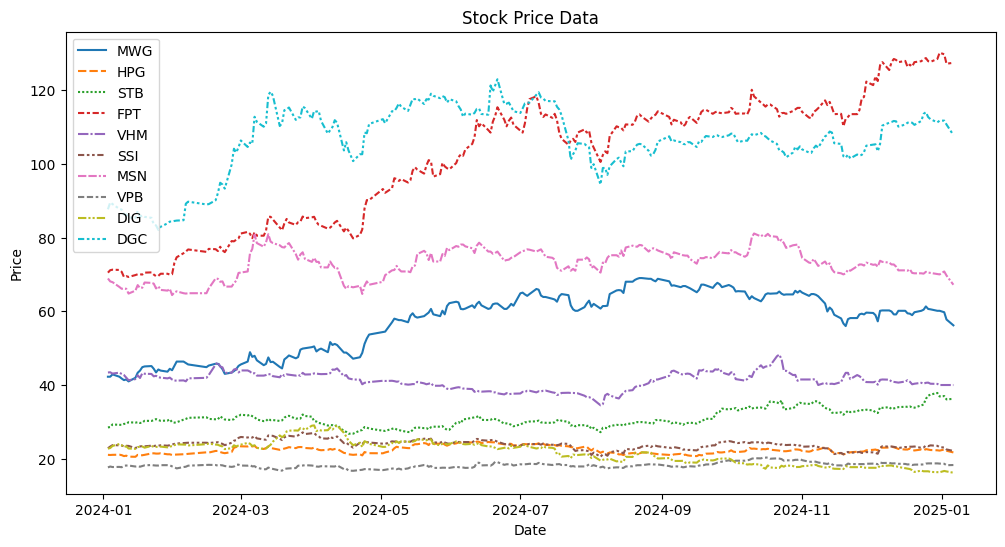

In [9]:
# plot example price data
plt.figure(figsize=(12, 6))
sns.lineplot(data=ex_price)
plt.title('Stock Price Data')
plt.xlabel('Date')
plt.ylabel('Price')

### Plot PC1

In [24]:
ex_pc1 = pca_result['V'][:, 0]

In [15]:
ex_stocks = pca_result['stocks']
ex_stocks_list = ex_stocks.tolist()

In [31]:
ex_stocks_industry = by_exchange[by_exchange['symbol'].isin(ex_stocks_list)].sort_values(['icb_code2', 'symbol'])[['symbol', 'icb_code2']]

In [32]:
ex_stocks_industry

,symbol,icb_code2
3098,BSR,500.0
746,PLX,500.0
683,PVB,500.0
682,PVC,500.0
681,PVD,500.0
...,...,...
1421,FPT,9500.0
1143,ICT,9500.0
1116,ITD,9500.0
611,SAM,9500.0


In [9]:
pc1_df = pd.DataFrame({
    'Stock': ex_stocks,
    'PC1 Loading': ex_pc1
})

In [23]:
print(len(stocks))

88


In [ ]:

# Tạo DataFrame từ danh sách stocks và industries
stock_and_industry = pd.DataFrame({
    'stock': stocks,
    'industry': industries
})

# In DataFrame
print(stock_and_industry)

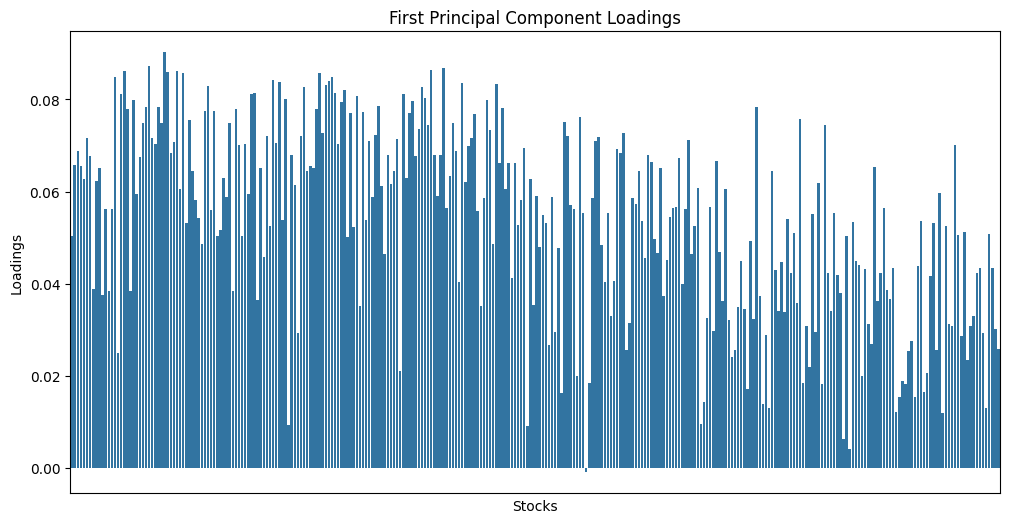

In [13]:
# visualixe the first principal component loadings
plt.figure(figsize=(12, 6))
sns.barplot(x=pc1_df_sorted['Stock'], y=pc1_df_sorted['PC1 Loading'])
plt.xticks([])
plt.title('First Principal Component Loadings')
plt.xlabel('Stocks')
plt.ylabel('Loadings')
plt.show()

In [121]:
pc1_df.sort_values('loading', ascending=False)

,stock,loading
61,SHS,0.115968
34,FPT,0.115744
23,ACB,0.112693
3,CTG,0.111847
14,SSI,0.111618
...,...,...
280,KSD,-0.001560
143,DNP,-0.002912
293,C69,-0.006297
255,CIG,-0.007152


### Plot PC2

In [33]:
ex_pc2 = pca_result['V'][:, 1]

In [34]:
pc2_df = pd.DataFrame({
    'Stock': ex_stocks,
    'PC2 Loading': ex_pc2
})

In [42]:
pc2_df[pc2_df['Stock'] == 'ST8']

,Stock,PC2 Loading
148,ST8,0.032291


In [55]:
pc2_df_industry =pc2_df.join(ex_stocks_industry.set_index('symbol'), on='Stock').sort_values(['icb_code2', 'Stock'])

In [56]:
pc2_df_industry['icb_code2'] = pc2_df_industry['icb_code2'].astype(int)

In [59]:
pc2_df_industry['icb_code2'].value_counts()

icb_code2
8600    55
2300    45
8700    26
2700    23
3500    23
1700    20
8300    19
1300    18
7500    14
3700    13
4500    10
9500     7
500      6
3300     6
8500     5
5300     5
5700     4
5500     1
Name: count, dtype: int64

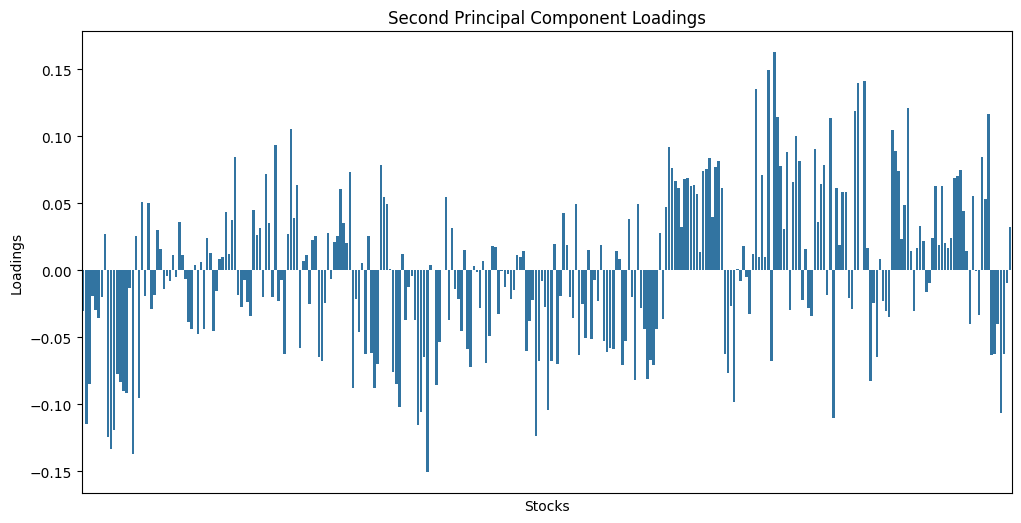

In [44]:
# visualixe the second principal component loadings
plt.figure(figsize=(12, 6))
sns.barplot(x=pc2_df_industry['Stock'], y=pc2_df_industry['PC2 Loading'])
plt.xticks([])
plt.title('Second Principal Component Loadings')
plt.xlabel('Stocks')
plt.ylabel('Loadings')
plt.show()

In [60]:
industries = sorted(pc2_df_industry['icb_code2'].unique())

palette = dict(zip(
    industries,
    sns.color_palette("tab20", n_colors=len(industries))
))

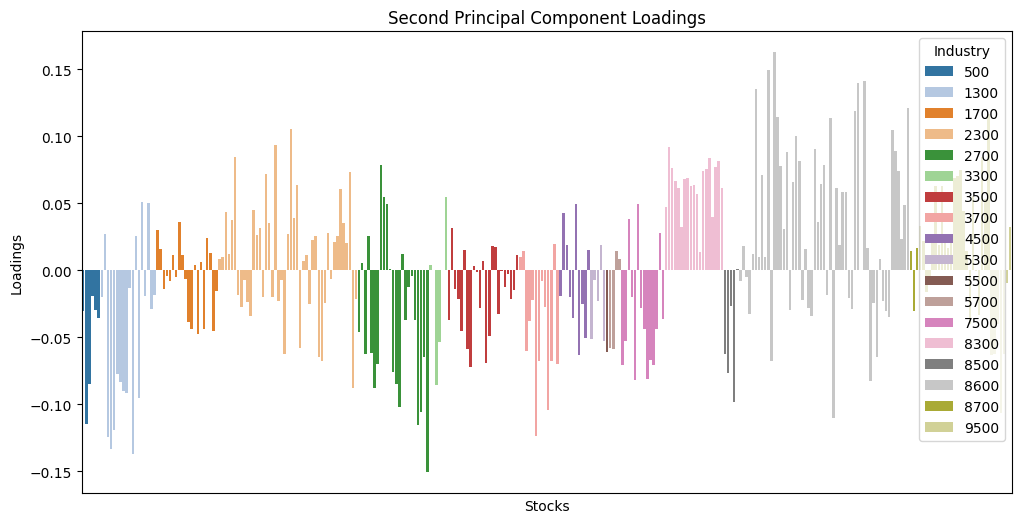

In [61]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=pc2_df_industry,
    x='Stock',
    y='PC2 Loading',
    hue='icb_code2',   # 👈 thêm dòng này
    palette=palette
)

plt.xticks([])
plt.title('Second Principal Component Loadings')
plt.xlabel('Stocks')
plt.ylabel('Loadings')

plt.legend(title='Industry')  # hiển thị chú thích màu
plt.show()

Computing factors over time...
Processed 249 trading days out of 367 calendar days


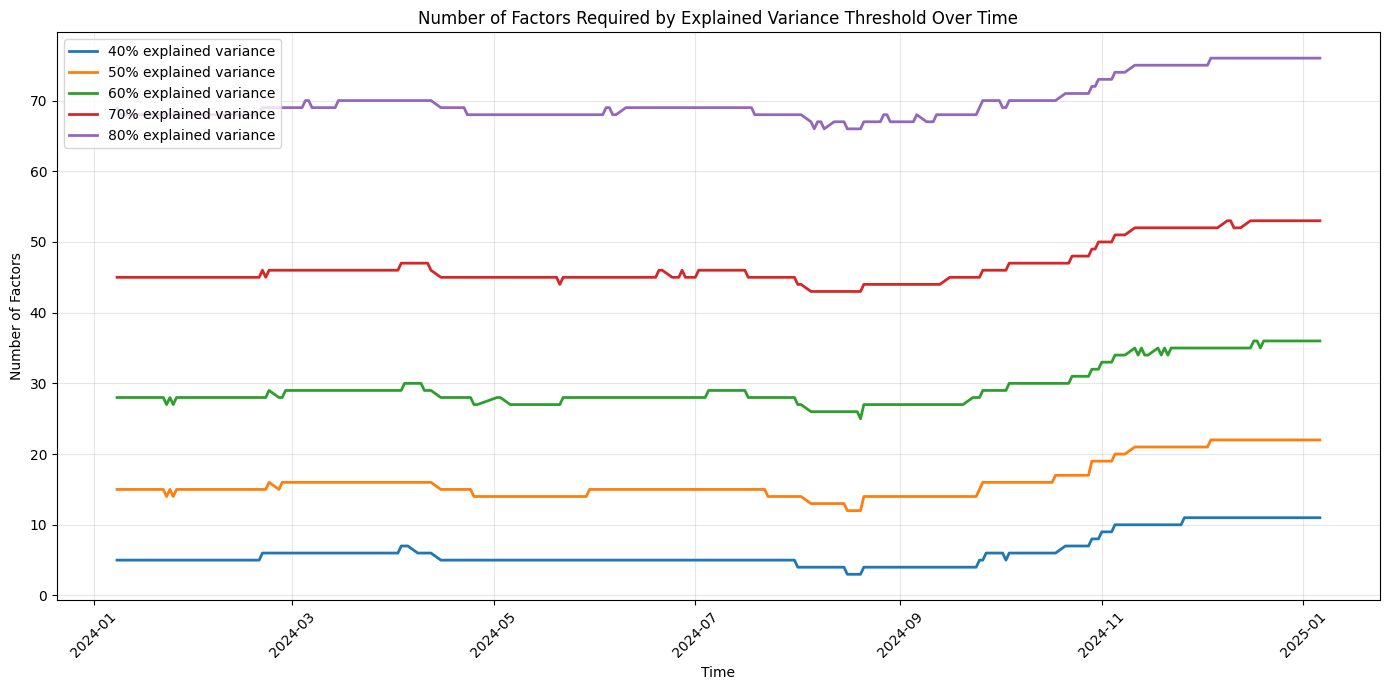

In [62]:
# Compute number of factors needed for different variance cutoffs over time
def compute_factors_over_time(prices_df, volumes_df, dates, variance_cutoffs=[0.4, 0.5, 0.6, 0.7, 0.8], 
                               top_n=300, lookback_window=252):
    """
    Calculate number of factors needed for each variance cutoff over time
    """
    results = {cutoff: [] for cutoff in variance_cutoffs}
    valid_dates = []
    
    for date in dates:
        # Check if date exists in dataset
        if date not in prices_df.index:
            continue
            
        try:
            price, volume = select_universe(prices_df, volumes_df, date=date, 
                                           top_n=top_n, lookback_window=lookback_window)
            returns = compute_returns(price, volume, volume_average_window=10)
            
            if returns.shape[1] >= 2:
                # Run PCA for each variance cutoff
                for cutoff in variance_cutoffs:
                    pca = window_pca_engine(returns, fixed_factors=False, variance_cutoff=cutoff)
                    results[cutoff].append(pca['k'])
                valid_dates.append(date)
        except:
            continue
    
    return valid_dates, results

# Run analysis
print("Computing factors over time...")
date_range = pd.date_range(start='2024-01-06', end='2025-01-06')
valid_dates, factor_counts = compute_factors_over_time(prices, volumes, date_range, 
                                                       variance_cutoffs=[0.4, 0.5, 0.6, 0.7, 0.8])

print(f"Processed {len(valid_dates)} trading days out of {len(date_range)} calendar days")

# Plot results
plt.figure(figsize=(14, 7))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for (cutoff, counts), color in zip(factor_counts.items(), colors):
    plt.plot(valid_dates, counts, label=f'{int(cutoff*100)}% explained variance', 
             linewidth=2, color=color)

plt.xlabel('Time')
plt.ylabel('Number of Factors')
plt.title('Number of Factors Required by Explained Variance Threshold Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

In [ ]:
# Compute number of factors needed for different variance cutoffs over time
def compute_eigenportfolios_over_time(prices_df, volumes_df, dates, 
                               top_n=300, lookback_window=252):
   
    
    valid_dates = []
    
    for date in dates:
        # Check if date exists in dataset
        if date not in prices_df.index:
            continue
            
        try:
            price, volume = select_universe(prices_df, volumes_df, date=date, 
                                           top_n=top_n, lookback_window=lookback_window)
            returns = compute_returns(price, volume, volume_average_window=10)
            
            if returns.shape[1] >= 2:
    
                pca = window_pca_engine(returns, fixed_factors=False, variance_cutoff=cutoff)
                results[cutoff].append(pca['k'])
                valid_dates.append(date)
        except:
            continue
    
    return valid_dates

### Plot Eigen Portfolio

In [11]:
import pandas as pd

In [9]:
por_price, por_volume = select_universe(prices, volumes, date=pd.to_datetime('2018-07-24'), top_n=300, lookback_window=252)
por_returns = compute_returns(por_price, por_volume, with_volume=False)
pca = window_pca_engine(por_returns, fixed_factors=False, variance_cutoff=0.55)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [31]:
por_returns.count()

STB    251
VJC    251
PVS    251
VNM    251
VIC    251
      ... 
DBT    251
UNI    251
CIG    251
HMC    251
KLB    251
Length: 300, dtype: int64

In [48]:
(por_volume == 0).sum()

STB     2
VJC     2
PVS     0
VNM     2
VIC     2
       ..
DBT    20
UNI     4
CIG    11
HMC     3
KLB    12
Length: 300, dtype: int64

In [61]:
prices.loc[['2018-07-17', '2018-07-16', '2018-07-13'], 'SCS']

2018-07-17    57.15
2018-07-16    57.73
2018-07-13    57.49
Name: SCS, dtype: float64

In [ ]:
por_volume[por_volume['SCS'] == 0]

2018-07-16    0.0
Name: SCS, dtype: float64

In [ ]:
prices

In [44]:
por_price['NTC']

2017-07-24    22.80
2017-07-25    23.60
2017-07-26    23.68
2017-07-27    23.60
2017-07-28    23.26
              ...  
2018-07-18    24.18
2018-07-19    24.14
2018-07-20    23.80
2018-07-23     0.00
2018-07-24    23.22
Name: NTC, Length: 252, dtype: float64

In [39]:
por_returns['SCS']

2017-07-25   -0.095946
2017-07-26    0.118834
2017-07-27   -0.028056
2017-07-28   -0.017182
2017-07-31    0.008392
                ...   
2018-07-18   -0.011899
2018-07-19    0.003010
2018-07-20   -0.006003
2018-07-23   -1.000000
2018-07-24         inf
Name: SCS, Length: 251, dtype: float64

In [18]:
por_std = por_returns.std(ddof=1)

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [32]:
por_std[por_std.isna()]

NTC   NaN
SCS   NaN
VIB   NaN
VCA   NaN
dtype: float64

In [19]:
por_valid_cols = por_std[(por_std > 0) & por_std.notna()].index

In [20]:
por_valid_cols

Index(['STB', 'VJC', 'PVS', 'VNM', 'VIC', 'NVL', 'CTG', 'VCB', 'MSN', 'SBT',
       ...
       'HKT', 'DP3', 'HJS', 'HAT', 'SHP', 'DBT', 'UNI', 'CIG', 'HMC', 'KLB'],
      dtype='object', length=296)

In [8]:
pca['stocks']

Index(['STB', 'VJC', 'PVS', 'VNM', 'VIC', 'NVL', 'CTG', 'VCB', 'MSN', 'SBT',
       ...
       'HKT', 'DP3', 'HJS', 'HAT', 'SHP', 'DBT', 'UNI', 'CIG', 'HMC', 'KLB'],
      dtype='object', length=296)

In [6]:
pca['Q'].shape

(296, 44)

In [12]:
return_pc1 = {}
for date in pd.date_range(pd.to_datetime(START_DATE), pd.to_datetime(END_DATE)):
    if date not in prices.index:
        continue
    try:
        price, volume = select_universe(prices, volumes, date=date, top_n=300, lookback_window=252)
        returns = compute_returns(price, volume, with_volume=False)
        pca = window_pca_engine(returns, fixed_factors=False, variance_cutoff=0.55)
        
        weight_pc1 = pca['Q'][:, 0]
        current_return = returns.iloc[-1].values
        factor_return_pc1 = current_return @ weight_pc1
        return_pc1[date] = factor_return_pc1
    except Exception as e:
        print(f"Error processing date {date}: {e}")

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Error processing date 2018-07-24 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 296 is different from 300)
Error processing date 2018-07-25 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 296 is different from 300)
Error processing date 2018-07-26 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 297 is different from 300)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Error processing date 2018-07-27 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 297 is different from 300)
Error processing date 2018-07-30 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 297 is different from 300)
Error processing date 2018-07-31 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 297 is different from 300)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


...

c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Error processing date 2019-07-18 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 298 is different from 300)
Error processing date 2019-07-19 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 298 is different from 300)
Error processing date 2019-07-22 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 298 is different from 300)


c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\ASUS\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


Error processing date 2019-07-23 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 298 is different from 300)
Error processing date 2019-07-24 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 298 is different from 300)
Error processing date 2019-07-25 00:00:00: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 298 is different from 300)


KeyboardInterrupt: 